# VN30 Stock Classification with MLP
Phân tích dữ liệu train/test của 30 mã cổ phiếu và huấn luyện MLP.

In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
import glob, os
import matplotlib.pyplot as plt

In [3]:
# ánh xạ nhãn
label_mapping = {"up":0, "down":1}
print("Label mapping:", label_mapping)

Label mapping: {'up': 0, 'down': 1}


In [4]:
class StockDataset(Dataset):
    def __init__(self, dataframe, seq_length=5, scaler=None):
        self.data = dataframe.copy()
        self.seq_length = seq_length
        self.features = ['open','high','low','close']
        self.label_mapping = {"up":0, "down":1}

        if scaler is None:
            self.scaler = StandardScaler()
            scaled_values = self.scaler.fit_transform(self.data[self.features])
        else:
            self.scaler = scaler
            scaled_values = self.scaler.transform(self.data[self.features])
        self.data[self.features] = scaled_values

    def __len__(self):
        return len(self.data) - self.seq_length + 1

    def __getitem__(self, idx):
        X = self.data.iloc[idx:idx+self.seq_length][self.features].values
        y = self.data.iloc[idx+self.seq_length-1]['label']
        y = self.label_mapping[y]
        return torch.FloatTensor(X), torch.tensor(int(y), dtype=torch.long)

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [6]:
def train_and_evaluate(train_df, test_df, stock_code, seq_length=5, epochs=5, batch_size=32):
    train_dataset = StockDataset(train_df, seq_length)
    test_dataset = StockDataset(test_df, seq_length, scaler=train_dataset.scaler)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = MLP(input_dim=seq_length*len(train_dataset.features)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Train loop
    for epoch in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = balanced_accuracy_score(all_labels, all_preds)
    print(f"{stock_code}: Balanced Acc = {acc:.4f}")
    return acc

Số mẫu train: 1245
Tỉ lệ nhãn:
label
down    0.529317
up      0.470683
Name: proportion, dtype: float64


,open,high,low,close,volume
count,1245.000000,1245.000000,1245.000000,1245.000000,1.245000e+03
mean,13.879815,14.044651,13.713044,13.876859,5.227553e+06
std,4.682296,4.717562,4.637097,4.674356,4.397150e+06
min,5.560000,6.490000,5.560000,6.150000,2.820880e+05
25%,8.220000,8.340000,8.120000,8.220000,2.113996e+06
50%,15.580000,15.790000,15.400000,15.580000,3.980631e+06
75%,18.240000,18.400000,18.020000,18.210000,7.009200e+06
max,21.330000,21.440000,20.460000,21.300000,3.515600e+07


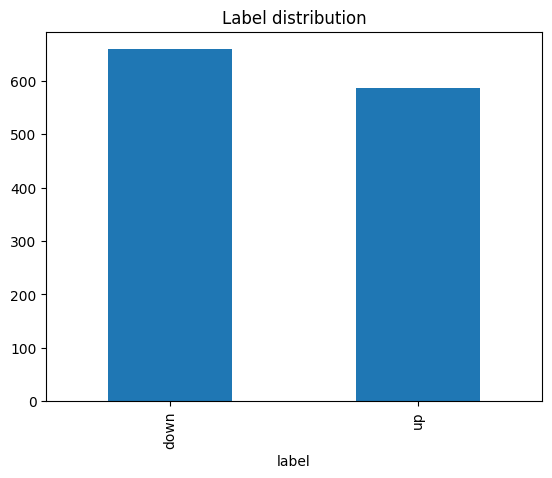

In [7]:
 # Đọc và phân tích 1 file 
sample = pd.read_csv(r'D:\Github_Local_path\EL4TF\data\vn30\binary\ACB_train.csv')
print("Số mẫu train:", len(sample))
print("Tỉ lệ nhãn:")
print(sample['label'].value_counts(normalize=True))
display(sample.describe())
sample['label'].value_counts().plot(kind='bar', title='Label distribution')
plt.show()

In [8]:

data_dir = r"D:/Github_Local_path/EL4TF/data/vn30/binary"   

results = []
train_files = glob.glob(os.path.join(data_dir, '*_train.csv'))

print(" Số file train tìm được:", len(train_files))

for train_file in train_files:
    code = os.path.basename(train_file).replace('_train.csv','')
    test_file = os.path.join(data_dir, f"{code}_test.csv")
    
    if not os.path.exists(test_file):
        print(f" Bỏ qua {code} vì không tìm thấy {test_file}")
        continue
    
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    
    acc = train_and_evaluate(train_df, test_df, code)
    print(f" {code}: Balanced Accuracy = {acc}")
    
    results.append({"Stock": code, "Balanced Accuracy": acc})

# Xuất kết quả
results_df = pd.DataFrame(results)
print("\n Kết quả tổng hợp:")
display(results_df)

# Lưu kết quả cùng thư mục data
# output_path = os.path.join(data_dir, 'results.csv')
# results_df.to_csv(output_path, index=False)
# print(f"\n Đã lưu vào {output_path}")


 Số file train tìm được: 30
ACB: Balanced Acc = 0.5000
 ACB: Balanced Accuracy = 0.5
BCM: Balanced Acc = 0.5000
 BCM: Balanced Accuracy = 0.5
BID: Balanced Acc = 0.5333
 BID: Balanced Accuracy = 0.5333333333333333
BVH: Balanced Acc = 0.5533
 BVH: Balanced Accuracy = 0.5533385093167702
CTG: Balanced Acc = 0.5000
 CTG: Balanced Accuracy = 0.5
FPT: Balanced Acc = 0.5301
 FPT: Balanced Accuracy = 0.5301204819277109
GAS: Balanced Acc = 0.6902
 GAS: Balanced Accuracy = 0.6901754666453495
GVR: Balanced Acc = 0.5333
 GVR: Balanced Accuracy = 0.5333231660820497
HDB: Balanced Acc = 0.6843
 HDB: Balanced Accuracy = 0.6843290704332888
HPG: Balanced Acc = 0.5360
 HPG: Balanced Accuracy = 0.5359517791172468
LPB: Balanced Acc = 0.5030
 LPB: Balanced Accuracy = 0.5029940119760479
MBB: Balanced Acc = 0.5000
 MBB: Balanced Accuracy = 0.5
MSN: Balanced Acc = 0.5000
 MSN: Balanced Accuracy = 0.5
MWG: Balanced Acc = 0.5634
 MWG: Balanced Accuracy = 0.5633924128162922
PLX: Balanced Acc = 0.5322
 PLX: Balanc

,Stock,Balanced Accuracy
0,ACB,0.500000
1,BCM,0.500000
2,BID,0.533333
3,BVH,0.553339
4,CTG,0.500000
5,FPT,0.530120
6,GAS,0.690175
7,GVR,0.533323
8,HDB,0.684329
9,HPG,0.535952
